# 03_train.ipynb — PatchTST GPU 学習

このノートブックでやること:
- PatchTST モデルの定義
- GPU 学習ループ（early stopping 付き）
- 学習曲線の確認
- モデルの保存

In [ ]:
!pip install -q "transformers>=4.41.0" accelerate
!pip install -q japanize-matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import numpy as np
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import PatchTSTConfig, PatchTSTForPrediction
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

DATA_LSTM_PROC = Path('/content/drive/MyDrive/project/weather-lstm/processed')
DATA_LSTM_RAW  = Path('/content/drive/MyDrive/project/weather-lstm/raw')
DATA_PROC      = Path('/content/drive/MyDrive/project/weather-patchtst/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'デバイス: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ハイパーパラメータ
SEQ_LEN    = 60   # 30→60: PatchTSTは長い文脈が必要（元論文は336〜720）
PRED_LEN   = 7
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 1e-4
PATIENCE   = 7

デバイス: cuda
GPU: Tesla T4


## 1. データ読み込みと前処理（seq_len=60 で再生成）

seq_len を変えたため `.npy` を再生成します。  
生データ（第3弾の CSV）から読み直します。

In [4]:
import pandas as pd

# 生データ読み込み（第3弾と同じCSV）
df = pd.read_csv(
    DATA_LSTM_RAW / 'tokyo_temperature.csv',
    encoding='CP932', skiprows=5, header=None,
    names=['date', 'temp', 'quality', 'homogeneous'],
    parse_dates=['date'], index_col='date',
)
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
values = df[['temp']].values  # (3653, 1)

# train/val/test 分割
n = len(values)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

# scaler は train のみで fit
scaler = MinMaxScaler()
scaler.fit(values[:train_end])
scaled = scaler.transform(values)

# スライディングウィンドウ（seq_len=60）
def make_sequences(data, seq_len, pred_len):
    X, y = [], []
    data = data.flatten()
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len : i + seq_len + pred_len])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(scaled, SEQ_LEN, PRED_LEN)

n_seq = len(X_all)
train_end_seq = int(n_seq * 0.7)
val_end_seq   = int(n_seq * 0.85)

X_train, y_train = X_all[:train_end_seq],            y_all[:train_end_seq]
X_val,   y_val   = X_all[train_end_seq:val_end_seq], y_all[train_end_seq:val_end_seq]
X_test,  y_test  = X_all[val_end_seq:],              y_all[val_end_seq:]

print(f'seq_len={SEQ_LEN} で再生成:')
print(f'  train: {X_train.shape}')
print(f'  val:   {X_val.shape}')
print(f'  test:  {X_test.shape}')

# 保存
np.save(DATA_PROC / 'X_train.npy', X_train); np.save(DATA_PROC / 'y_train.npy', y_train)
np.save(DATA_PROC / 'X_val.npy',   X_val);   np.save(DATA_PROC / 'y_val.npy',   y_val)
np.save(DATA_PROC / 'X_test.npy',  X_test);  np.save(DATA_PROC / 'y_test.npy',  y_test)
import pickle
with open(DATA_PROC / 'scaler.pkl', 'wb') as f: pickle.dump(scaler, f)

class WeatherDatasetPatchTST(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(WeatherDatasetPatchTST(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(WeatherDatasetPatchTST(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
print('DataLoader 準備完了')

seq_len=60 で再生成:
  train: (2510, 60)
  val:   (538, 60)
  test:  (539, 60)
DataLoader 準備完了


## 2. PatchTST モデル定義

パッチ数の計算:
```
num_patches = (context_length - patch_length) / stride + 1
           = (60 - 6) / 2 + 1 = 28 patches
```

> ⚠️ **設計変更メモ（途中変更）**  
> 初期設計: `seq_len=30, stride=1` → 25 patches（`02_dataset.ipynb` の設計）  
> 現在: `seq_len=60, stride=2` → 28 patches  
> **理由**: PatchTST は長い文脈が有効（元論文は336〜720）なため、より長い入力窓に変更した。  
> あわせて `d_model=128→64`、`num_hidden_layers=3→2` もスリム化している。

各パッチが 1 つの token として Transformer Encoder に入力されます。  
LSTM が 30 ステップを逐次処理するのに対し、PatchTST は 28 トークンを並列処理します。

In [5]:
config = PatchTSTConfig(
    num_input_channels=1,
    context_length=SEQ_LEN,     # 60
    prediction_length=PRED_LEN, # 7
    patch_length=6,
    stride=2,           # stride=2: (60-6)/2+1=28 patches（適切なトークン数）
    d_model=64,
    num_attention_heads=4,
    num_hidden_layers=2,
    ffn_dim=128,
    dropout=0.3,
    head_dropout=0.3,
    pooling_type='mean',
)

model = PatchTSTForPrediction(config).to(device)

n_params = sum(p.numel() for p in model.parameters())
num_patches = (SEQ_LEN - 6) // 2 + 1
print(f'パラメータ数: {n_params:,}')
print(f'パッチ数: (60 - 6) / 2 + 1 = {num_patches} patches  (前回: 25 patches)')

パラメータ数: 71,367
パッチ数: (60 - 6) / 2 + 1 = 28 patches  (前回: 25 patches)


## 3. 学習ループ（Early Stopping 付き）

Early Stopping: val_loss が `PATIENCE` エポック改善しなかったら学習を打ち切る。  
過学習を防ぎつつ、100エポック待たずに最良モデルを保存できます。

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)  # 1e-4→1e-3
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()

best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(past_values=X_batch)
        pred = output.prediction_outputs  # (B, 7, 1)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # --- val ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output = model(past_values=X_batch)
            pred = output.prediction_outputs
            val_loss += criterion(pred, y_batch).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | train: {train_loss:.5f} | val: {val_loss:.5f}')

    # --- early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), DATA_PROC / 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}  (best val_loss: {best_val_loss:.5f})')
            break

print(f'\n最良 val_loss: {best_val_loss:.5f}')

Epoch   1/100 | train: 0.02000 | val: 0.00901
Epoch  10/100 | train: 0.00764 | val: 0.00717

Early stopping at epoch 16  (best val_loss: 0.00710)

最良 val_loss: 0.00710


## 4. 学習曲線

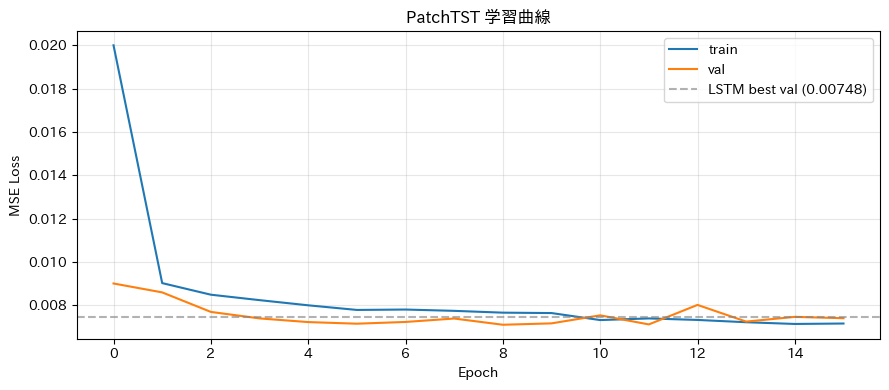

LSTM  best val_loss: 0.00748
PatchTST best val_loss: 0.00710
→ PatchTST が 0.00038 改善 ✅


In [7]:
import japanize_matplotlib

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('PatchTST 学習曲線')
plt.legend()
plt.grid(True, alpha=0.3)

# 第3弾の最終val_lossを参考線として表示
LSTM_BEST_VAL = 0.00748
plt.axhline(y=LSTM_BEST_VAL, color='gray', linestyle='--', alpha=0.6, label=f'LSTM best val ({LSTM_BEST_VAL})')
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROC / 'learning_curve.png', dpi=150)
plt.show()

print(f'LSTM  best val_loss: {LSTM_BEST_VAL:.5f}')
print(f'PatchTST best val_loss: {best_val_loss:.5f}')
diff = LSTM_BEST_VAL - best_val_loss
if diff > 0:
    print(f'→ PatchTST が {diff:.5f} 改善 ✅')
else:
    print(f'→ LSTM の方が {-diff:.5f} 優勢（ハイパーパラメータ調整の余地あり）')

## 5. モデルと config を保存

In [8]:
# config も保存（04_compare で同じモデルを再現するために必要）
config.save_pretrained(str(DATA_PROC / 'config'))

# 学習履歴も保存
np.save(DATA_PROC / 'train_losses.npy', np.array(train_losses))
np.save(DATA_PROC / 'val_losses.npy',   np.array(val_losses))

print('保存完了:')
for p in sorted(DATA_PROC.glob('**/*')):
    if p.is_file():
        print(f'  {p.relative_to(DATA_PROC)}')

保存完了:
  X_test.npy
  X_train.npy
  X_val.npy
  best_model.pth
  config/config.json
  learning_curve.png
  scaler.pkl
  train_losses.npy
  val_losses.npy
  y_test.npy
  y_train.npy
  y_val.npy


## 確認チェックリスト

- [ ] GPU で学習が走った（`デバイス: cuda`）
- [ ] `best_model.pth` が保存された
- [ ] 学習曲線で train/val が収束している
- [ ] LSTM の val_loss（0.00748）と比較した

すべてOKなら `04_compare.ipynb` へ進んでください。